In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [30]:
def read_metrics_file(directories):
    all_dfs = []
    for dir in directories:
        for root, dirs, files in os.walk(dir):
            for file in files:
                if "test_metrics" in file:
                    df = pd.read_csv(os.path.join(root, file))
                    df["model"] = root.split("/")[-4]
                    df["parent"] = os.path.basename(os.path.dirname(root))
                    df["dataset"] = root.split("/")[-3]
                    df["run"] = os.path.basename(root)
                    df.index = range(len(df))

                    all_dfs.append(df)

    df = pd.concat(all_dfs)
    return df


def get_stats(df):
    metrics = ["test_cls_loss", "test_cls_acc", "test_cls_ece"]
    stats_df = df.groupby(["parent", "checkpoint", "model", "dataset"])[metrics].agg(["mean", "std"])

    # Flatten the multi-level column names
    stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]

    # Reset index to make parent and checkpoint regular columns
    stats_df = stats_df.reset_index()

    # Sort by parent and checkpoint number
    stats_df["checkpoint_num"] = stats_df["checkpoint"].str.extract(r"(\d+)").astype(float).astype("Int64")
    stats_df = stats_df.sort_values(["parent", "checkpoint_num", "model"])
    stats_df = stats_df.drop("checkpoint_num", axis=1)

    return stats_df


base_dir = os.path.dirname(os.getcwd())
directories = [os.path.join(base_dir, "results")]

metrics = read_metrics_file(directories)
metrics = get_stats(metrics).fillna(0)
metrics

,parent,checkpoint,model,dataset,test_cls_loss_mean,test_cls_loss_std,test_cls_acc_mean,test_cls_acc_std,test_cls_ece_mean,test_cls_ece_std
0,baseline,model-best_val_ece,wrn,bloodmnist_256,0.079716,0.006004,0.985618,0.000837,0.013341,0.000601
1,baseline,model-best_val_ece,wrn,organamnist_256,0.188646,0.026496,0.938051,0.007562,0.035386,0.003979
2,baseline,model-best_val_loss,wrn,bloodmnist_256,0.072525,0.003325,0.983221,0.002316,0.015993,0.001575
3,baseline,model-best_val_loss,wrn,organamnist_256,0.162929,0.011062,0.952188,0.003083,0.034314,0.002568
4,baseline,model-final,wrn,bloodmnist_256,0.083743,0.005453,0.985618,0.000757,0.013474,0.000702
...,...,...,...,...,...,...,...,...,...,...
29,lc,al_iter_11-best_val_ece,wrn,bloodmnist_256,0.100535,0.010362,0.980415,0.001323,0.018408,0.001291
30,lc,al_iter_11-best_val_ece,wrn,organamnist_256,0.268120,0.000000,0.955394,0.000000,0.038606,0.000000
33,lc,al_iter_11-best_val_loss,wrn,bloodmnist_256,0.098818,0.010118,0.980474,0.001842,0.017945,0.001067
34,lc,al_iter_11-best_val_loss,wrn,organamnist_256,0.258656,0.000000,0.954269,0.000000,0.039396,0.000000


In [40]:
# get only rows with 'final in checkpoint
metric_to_compare = "test_cls_ece"
dataset_to_query = "bloodmnist_256"

egc_final_metrics = metrics.query('checkpoint.str.contains("final") and model.str.contains("egc") and dataset in @dataset_to_query')
egc_best_ece_metrics = metrics.query('checkpoint.str.contains("ece") and model.str.contains("egc") and dataset in @dataset_to_query')
egc_best_loss_metrics = metrics.query('checkpoint.str.contains("loss") and model.str.contains("egc") and dataset in @dataset_to_query')

wrn_final_metrics = metrics.query('checkpoint.str.contains("final") and model.str.contains("wrn") and dataset in @dataset_to_query')
wrn_best_ece_metrics = metrics.query('checkpoint.str.contains("ece") and model.str.contains("wrn") and dataset in @dataset_to_query')
wrn_best_loss_metrics = metrics.query('checkpoint.str.contains("loss") and model.str.contains("wrn") and dataset in @dataset_to_query')

In [48]:
def plot_combined_stats(stats_dfs, title, labels=None):
    """
    Plot multiple dataframes with a shared legend and contrasting colors

    Args:
        stats_dfs: List of dataframes to plot
        title: Title for the figure
        labels: List of labels for each dataframe (optional)
    """
    metrics = ["test_cls_acc", "test_cls_ece"]
    titles = {"test_cls_acc_mean": "Accuracy (higher is better)", "test_cls_ece_mean": "ECE (lower is better)"}
    metric_names = {"test_cls_acc_mean": "Accuracy", "test_cls_ece_mean": "ECE"}

    # Create figure with extra space for legend at bottom
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

    # Define highly contrasting colors
    colors = [
        "#1f77b4",  # blue
        "#d62728",  # red
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#8c564b",  # brown
        "#e377c2",  # pink
        "#17becf",  # cyan
        "#bcbd22",
    ]  # olive

    markers = ["o"]

    # Store line objects for legend
    legend_elements = []

    for df_idx, stats_df in enumerate(stats_dfs):
        df_label = labels[df_idx] if labels else f"Experiment {df_idx + 1}"

        for parent in stats_df["parent"].unique():
            parent_data = stats_df[stats_df["parent"] == parent].copy()

            # Extract numeric values from checkpoint
            if parent_data["checkpoint"].dtype == "object":
                parent_data["checkpoint"] = parent_data["checkpoint"].str.extract(r"(\d+)").astype("Int64")

            # Sort by checkpoint
            parent_data = parent_data.sort_values("checkpoint")

            # Create label combining experiment and parent
            if parent == "baseline":
                plot_label = f"{df_label} ({parent})"
            else:
                plot_label = f"{df_label}"

            for i, metric in enumerate(metrics):
                mean_col = f"{metric}_mean"
                std_col = f"{metric}_std"

                line = axes[i].plot(
                    parent_data["checkpoint"],
                    parent_data[mean_col],
                    label=plot_label,
                    marker=markers[df_idx % len(markers)],
                    # linestyle="--" if parent != "baseline" else "-",
                    markersize=4,
                    color=colors[df_idx],
                    linewidth=2,
                )

                # Only add to legend for the first subplot to avoid duplicates
                if i == 0:
                    legend_elements.append(line[0])

                # Plot standard deviation if available
                if std_col in parent_data.columns and not parent_data[std_col].isna().all():
                    axes[i].fill_between(parent_data["checkpoint"], parent_data[mean_col] - parent_data[std_col], parent_data[mean_col] + parent_data[std_col], alpha=0.1, color=colors[df_idx])

                # Add baseline reference line
                if parent == "baseline":
                    axes[i].axhline(y=parent_data[mean_col].values[0], color="black", linestyle=":", linewidth=1.5)

    # Customize each subplot
    for i, metric in enumerate(metrics):
        mean_col = f"{metric}_mean"
        axes[i].legend()
        axes[i].set_title(titles[mean_col], fontsize=12, pad=10)
        axes[i].set_xlabel("Cycle", fontsize=10)
        axes[i].set_ylabel(metric_names[mean_col], fontsize=10)
        # axes[i].grid(True, alpha=0.3, linestyle="--")
        axes[i].tick_params(axis="both", which="major", labelsize=9)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

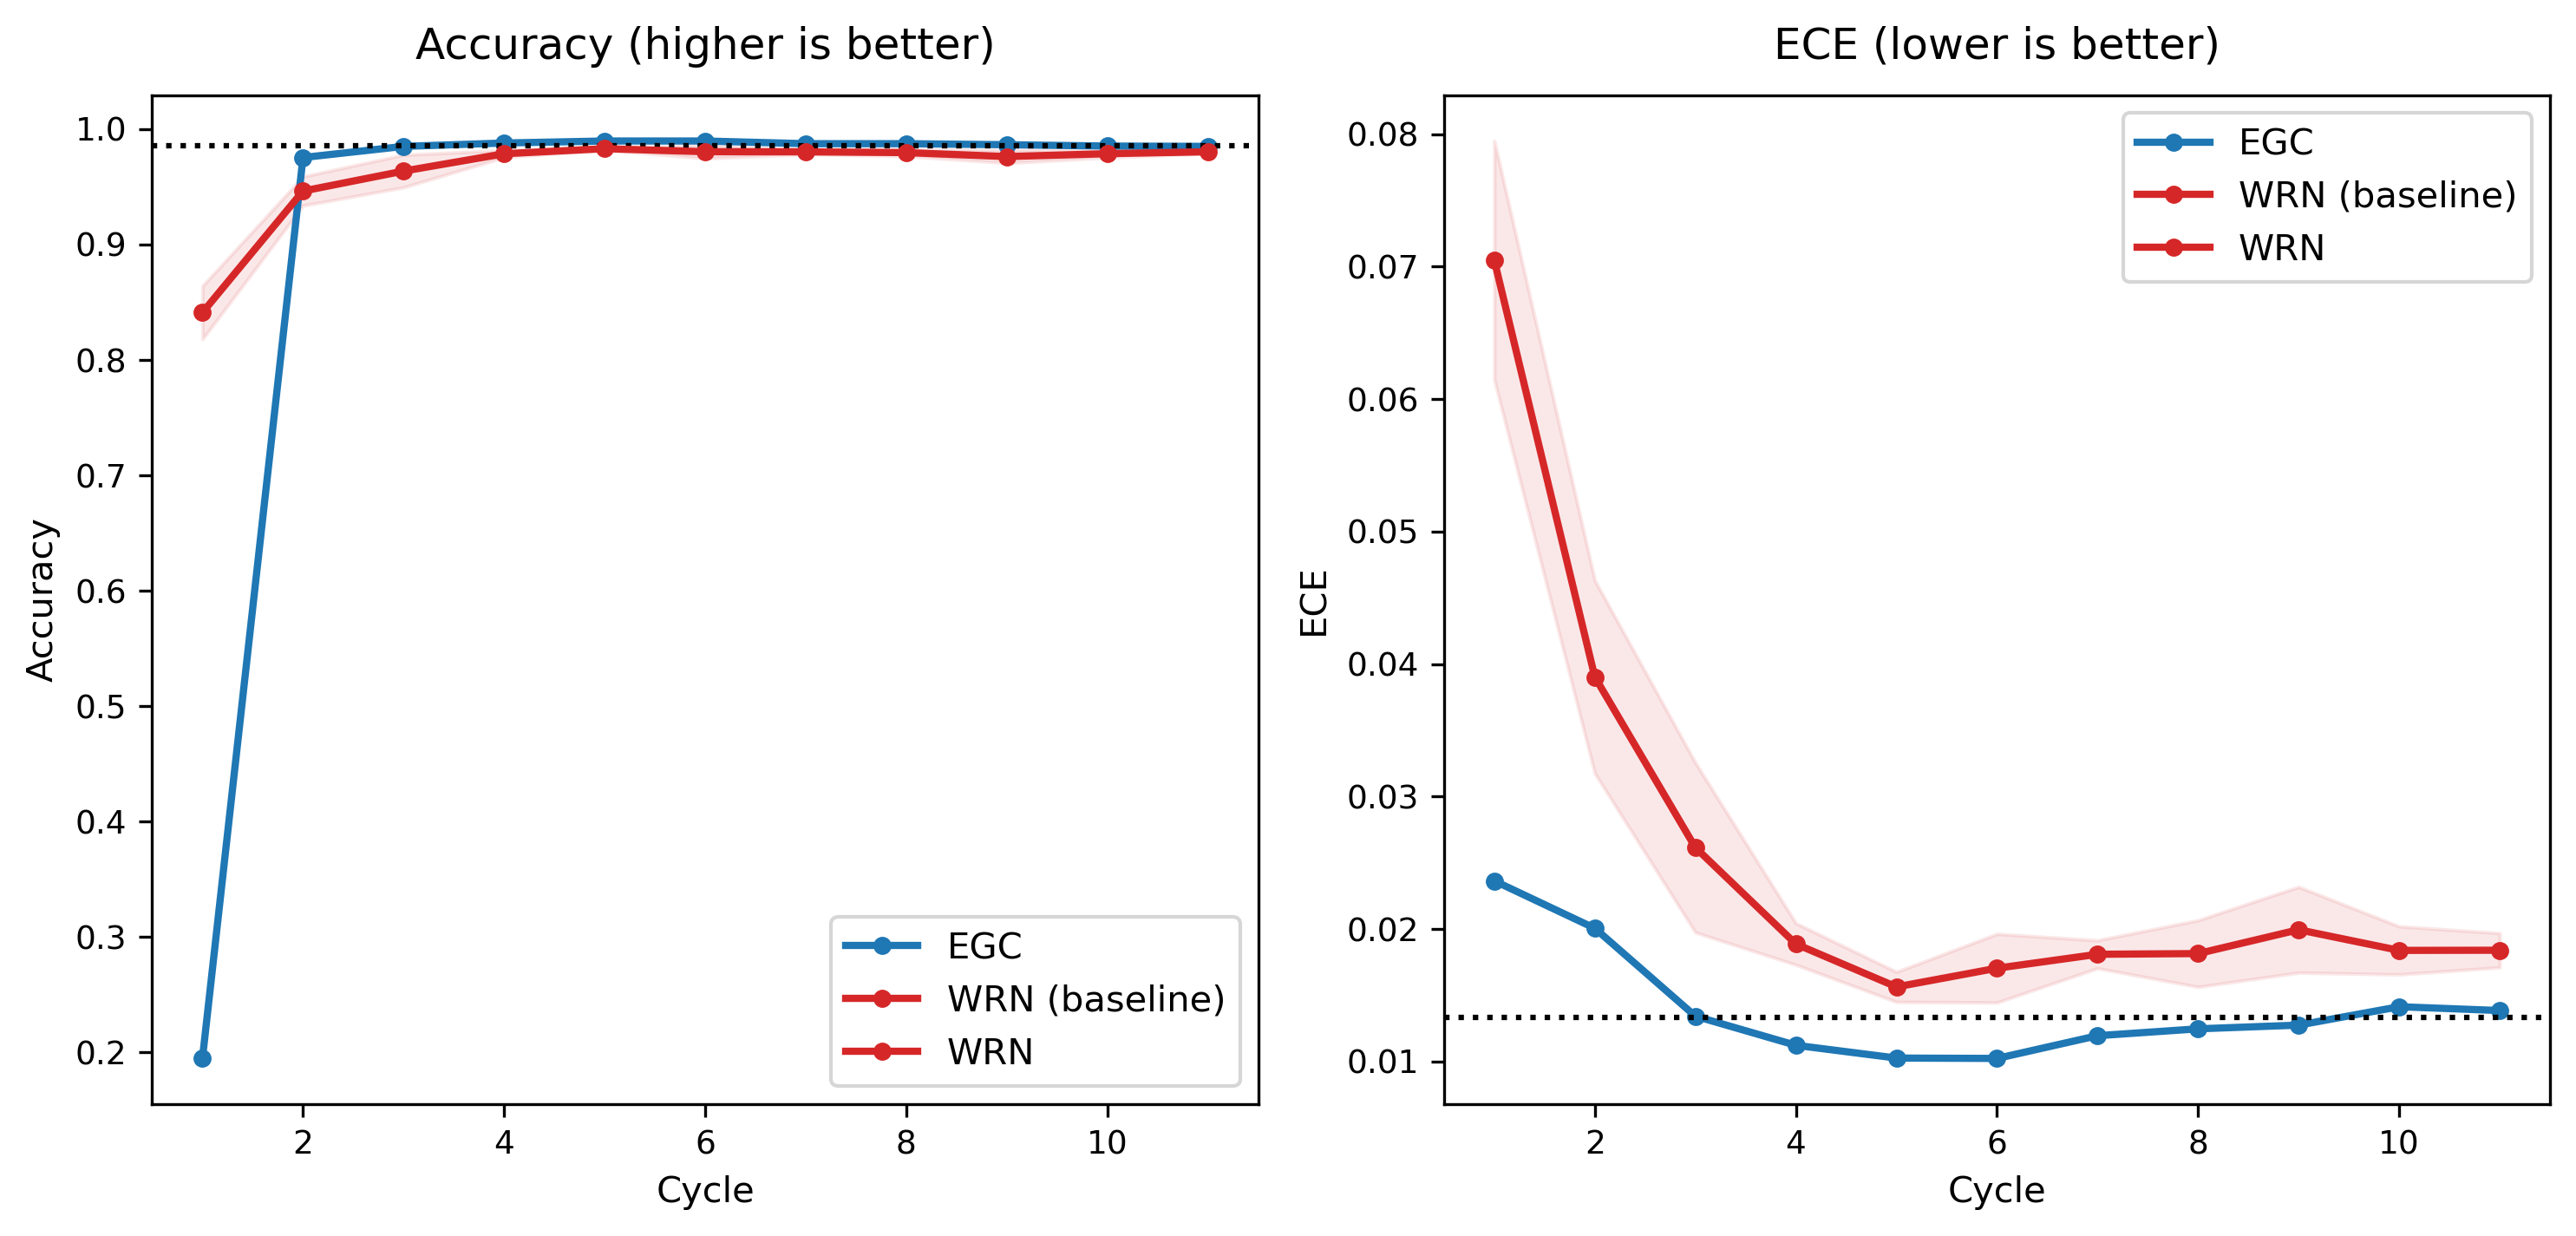

In [49]:
dfs = [egc_best_ece_metrics, wrn_best_ece_metrics]
labels = ["EGC", "WRN"]
plot_combined_stats(dfs, "", labels=labels)